In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
All_data_df = pd.read_csv('../datasets/prepared_data/master_panel_country_year.csv')
All_data_df

,iso3,country,Year,oil_rents_pct_gdp,coal_rents_pct_gdp,gas_rents_pct_gdp,total_fossil_rents_pct_gdp,fossil_share_pct,coal_production_twh,oil_production_twh,gas_production_twh,total_production_twh,un_session
0,ABW,Aruba,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15
1,ABW,Aruba,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
2,ABW,Aruba,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17
3,ABW,Aruba,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18
4,ABW,Aruba,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14378,ZWE,Zimbabwe,2021,0.047769,0.290131,0.0,0.3379,NaN,24.290953,NaN,NaN,24.290953,76
14379,ZWE,Zimbabwe,2022,NaN,NaN,NaN,NaN,NaN,29.553642,NaN,NaN,29.553642,77
14380,ZWE,Zimbabwe,2023,NaN,NaN,NaN,NaN,NaN,37.412743,NaN,NaN,37.412743,78
14381,ZWE,Zimbabwe,2024,NaN,NaN,NaN,NaN,NaN,43.476120,NaN,NaN,43.476120,79


In [6]:
rents = (All_data_df[All_data_df['Year'].between(2015, 2021)]
         .groupby(['iso3', 'country'])['total_fossil_rents_pct_gdp']
         .mean()
         .dropna())

rents.describe()

count    202.000000
mean       3.016356
std        7.325240
min        0.000000
25%        0.000000
50%        0.064933
75%        1.395181
max       49.209593
Name: total_fossil_rents_pct_gdp, dtype: float64

In [12]:
Total_prod = (All_data_df[All_data_df['Year'].between(2015, 2021)]
         .groupby(['iso3', 'country'])['total_production_twh']
         .mean()
         .dropna())
Total_prod.describe()

count       73.000000
mean      1791.958361
std       4171.104944
min          6.792566
25%        103.082426
50%        366.511989
75%       1642.661903
max      25272.114471
Name: total_production_twh, dtype: float64

In [7]:
cutoff = rents.quantile(0.75)
exporters = rents[rents >= cutoff].sort_values(ascending=False)

print(f"top-quartile cutoff: {cutoff:.2f}% of GDP")
print(f"{len(exporters)} major fossil fuel exporters")
exporters

top-quartile cutoff: 1.40% of GDP
51 major fossil fuel exporters


iso3  country             
TLS   Timor-Leste             49.209593
IRQ   Iraq                    38.216496
KWT   Kuwait                  36.784715
LBY   Libya                   26.989971
COG   Congo, Rep.             26.267976
SAU   Saudi Arabia            23.881006
AGO   Angola                  23.771981
OMN   Oman                    22.937821
IRN   Iran, Islamic Rep.      21.990043
QAT   Qatar                   21.119025
AZE   Azerbaijan              20.194426
GNQ   Equatorial Guinea       19.560750
BRN   Brunei Darussalam       18.959111
DZA   Algeria                 16.809868
ARE   United Arab Emirates    14.981151
TKM   Turkmenistan            14.345421
GAB   Gabon                   13.648484
BHR   Bahrain                 12.699796
KAZ   Kazakhstan              12.265030
CPV   Cabo Verde              12.092242
TCD   Chad                    11.621246
SSD   South Sudan             10.391373
RUS   Russian Federation      10.179413
PNG   Papua New Guinea         8.239235
TTO   Trinida

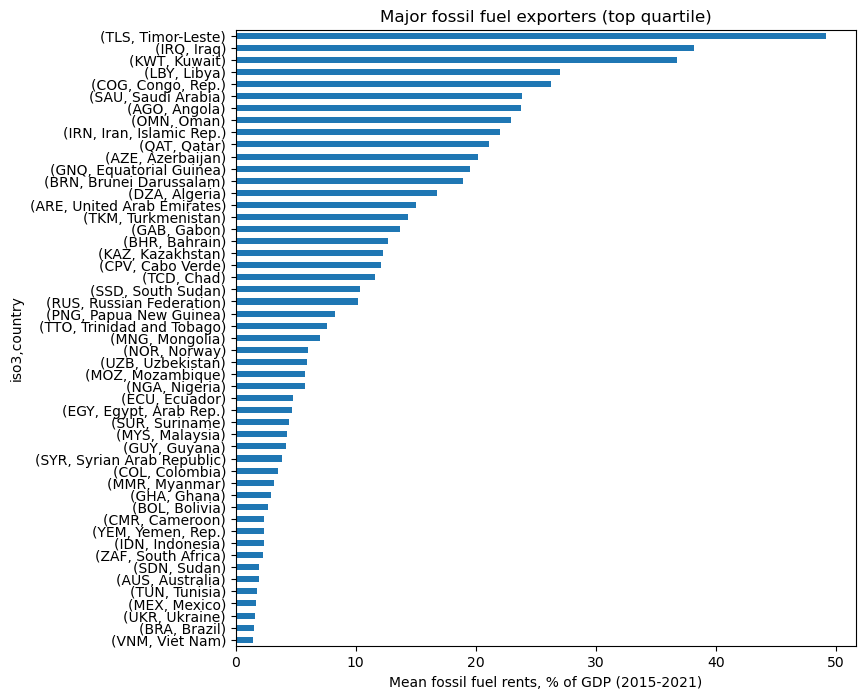

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
exporters.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Mean fossil fuel rents, % of GDP (2015-2021)')
ax.set_title('Major fossil fuel exporters (top quartile)')
plt.show()

In [14]:
cutoff = Total_prod.quantile(0.75)
producers = Total_prod[Total_prod >= cutoff].sort_values(ascending=False)

print(f"top-quartile cutoff: {cutoff:.2f}twh production")
print(f"{len(producers)} major fossil fuel producers")
producers

top-quartile cutoff: 1642.66twh production
19 major fossil fuel producers


iso3  country             
CHN   China                   25272.114471
USA   United States           19883.428586
RUS   Russian Federation      15255.016400
SAU   Saudi Arabia             7541.976457
AUS   Australia                4976.881659
CAN   Canada                   4914.612261
IRN   Iran, Islamic Rep.       4407.864129
IDN   Indonesia                4347.111590
IND   India                    4168.569186
QAT   Qatar                    2613.255696
IRQ   Iraq                     2584.454651
ARE   United Arab Emirates     2567.340299
NOR   Norway                   2175.886329
BRA   Brazil                   1972.630238
KAZ   Kazakhstan               1825.602787
KWT   Kuwait                   1804.444290
MEX   Mexico                   1714.807864
ZAF   South Africa             1648.037600
DZA   Algeria                  1642.661903
Name: total_production_twh, dtype: float64

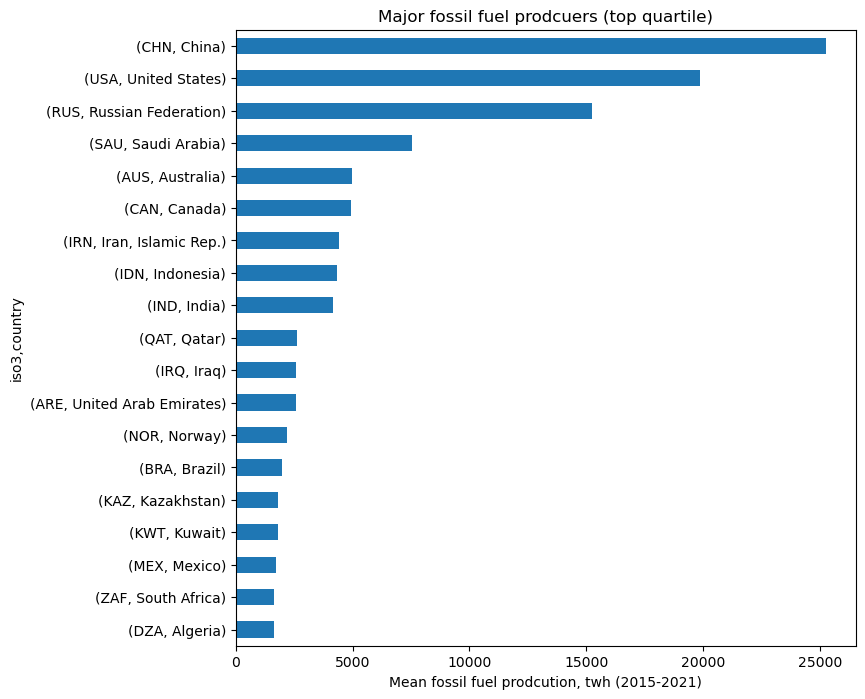

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
producers.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Mean fossil fuel prodcution, twh (2015-2021)')
ax.set_title('Major fossil fuel prodcuers (top quartile)')
plt.show()

In [24]:
producing_countries = producers.index.get_level_values('country')
exporters_countries = exporters.index.get_level_values('country')
top_countries = producing_countries.intersection(exporters_countries)
top_countries

Index(['Russian Federation', 'Saudi Arabia', 'Australia', 'Iran, Islamic Rep.',
       'Indonesia', 'Qatar', 'Iraq', 'United Arab Emirates', 'Norway',
       'Brazil', 'Kazakhstan', 'Kuwait', 'Mexico', 'South Africa', 'Algeria'],
      dtype='object', name='country')

In [33]:
consumption = (All_data_df[All_data_df['Year'] >= 2015]
               .dropna(subset=['fossil_share_pct'])
               .set_index(['iso3', 'country', 'Year'])['fossil_share_pct'])

consumption.describe()
consumption

iso3  country               Year
ARE   United Arab Emirates  2015    99.975410
                            2016    99.975100
                            2017    99.938450
                            2018    99.894035
                            2019    99.698650
                                      ...    
ZAF   South Africa          2021    95.752710
                            2022    95.642590
                            2023    95.909256
                            2024    95.985450
                            2025    95.268200
Name: fossil_share_pct, Length: 817, dtype: float64

In [34]:
consumption_top_countries = consumption[consumption.index.get_level_values('country').isin(top_countries)]
consumption_top_countries

iso3  country               Year
ARE   United Arab Emirates  2015    99.975410
                            2016    99.975100
                            2017    99.938450
                            2018    99.894035
                            2019    99.698650
                                      ...    
ZAF   South Africa          2021    95.752710
                            2022    95.642590
                            2023    95.909256
                            2024    95.985450
                            2025    95.268200
Name: fossil_share_pct, Length: 157, dtype: float64